### The aim of this analysis is to prepare a predictive model for the following clinical endpoints:
- INSS.Stage
- HighRisk
- DeathFromDisease
- Progression

pip3 install --user matplotlib-venn

In [1]:
# pre-emptively load libraries most likely to be used in initial analysis

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt # plotting and visulisation
import seaborn as sns # nicer (easier) visualisation
%matplotlib inline


# for saving
import os,os.path

In [2]:
# load data into environment
data_Dir = "data/"
patient_info = data_Dir + 'clinical_data_for_assessment_final.csv'
ma_vals = data_Dir + 'allProbIntensities_rawdata_final.csv'

In [3]:
# read patient data into DF
df_patient_info = pd.read_csv(patient_info)

In [4]:
df_patient_info

# 9 features: sample ID, gender, Age, clinico.genetic.subgroup, MYCN.status, INSS.Stage, HighRisk, Progression, DeathFromDisease
# Outcomes are: INSS.Stage, HighRisk, Death, Progression
# So will almost certainly divorce this from the other clinical features and merge the rest with the microarray data
# 373 rows = samples. Should be 498 so some have been dropped.

,ID,Gender,Age,clinico.genetic.subgroup,MYCN.status,INSS.Stage,HighRisk,Progression,DeathFromDisease
0,ICGC_001,M,987.0,ST4,1,4,HR,1,1
1,ICGC_002,M,1808.0,ST4,1,4,HR,1,1
2,ICGC_003,F,625.0,MNA,Amp,4,HR,1,1
3,ICGC_004,F,335.0,MNA,Amp,2b,HR,0,0
4,ICGC_005,F,536.0,MNA,Amp,4,HR,1,1
...,...,...,...,...,...,...,...,...,...
368,ICGC_494,M,56.0,ST1,1,1,LR,0,0
369,ICGC_495,M,163.0,ST1,1,1,LR,0,0
370,ICGC_496,M,132.0,ST1,1,1,LR,1,0
371,ICGC_497,F,379.0,ST1,1,1,LR,0,0


In [5]:
# determine if there is any missing data in patient info
print("\nCount of NaN in each column:\n", df_patient_info.isnull().sum())

# no missing data


Count of NaN in each column:
 ID                          0
Gender                      0
Age                         0
clinico.genetic.subgroup    0
MYCN.status                 0
INSS.Stage                  0
HighRisk                    0
Progression                 0
DeathFromDisease            0
dtype: int64


In [6]:
# observe frequency stats of MYCN status and clinico-genetic subgroup
pd.crosstab(df_patient_info['clinico.genetic.subgroup'], df_patient_info['MYCN.status']) 

# cg_sub and MYCN will almost certainly track together, with MYCN splitting in two and then the next splits happening with cg_sub

MYCN.status,1,Amp
clinico.genetic.subgroup,,
MNA,0,92
ST1,117,0
ST4,116,0
ST4S,48,0


In [7]:
# observe frequency stats of Death and Progression 
pd.crosstab(df_patient_info['Progression'], df_patient_info['DeathFromDisease']) 

# If progression is 0 there is no death from disease, but if progression is 1, then there is a 100/50 split into death/not_death
# DeathFromDisease cat 0 = 277; cat 1 = 96 (65/35 split)

DeathFromDisease,0,1
Progression,,
0,226,0
1,51,96


In [8]:
# Crosstab with Multiple Factors
ct = pd.crosstab(
    index=[df_patient_info["Gender"], df_patient_info["HighRisk"]],   # Multiple factors as row index
    columns=df_patient_info["DeathFromDisease"],         # Single factor as column
    margins=True                            # Adds row/column totals
)
ct

DeathFromDisease    0   1  All
Gender HighRisk               
F      HR          25  39   64
       LR          87   4   91
M      HR          59  52  111
       LR         106   1  107
All               277  96  373

In [9]:
# Very slight imbalance with 218 males and 155 females (58/42)
pd.crosstab(df_patient_info['Gender'], 'gender_num')

col_0,gender_num
Gender,
F,155
M,218


In [10]:
## Deeper dive into patient data; create reusable function to print and plot comparisons

def cross_comparison(factor1 = None, factor2 = None ):
    factor1_vs_factor2 = pd.DataFrame(pd.crosstab(df_patient_info[factor1], df_patient_info[factor2]))
    print(factor1_vs_factor2)
    factor1_vs_factor2.plot.bar()


MYCN.status    1  Amp
Gender               
F            111   44
M            170   48
DeathFromDisease    0   1
Gender                   
F                 112  43
M                 165  53
HighRisk   HR   LR
Gender            
F          64   91
M         111  107
DeathFromDisease    0   1
MYCN.status              
1                 236  45
Amp                41  51


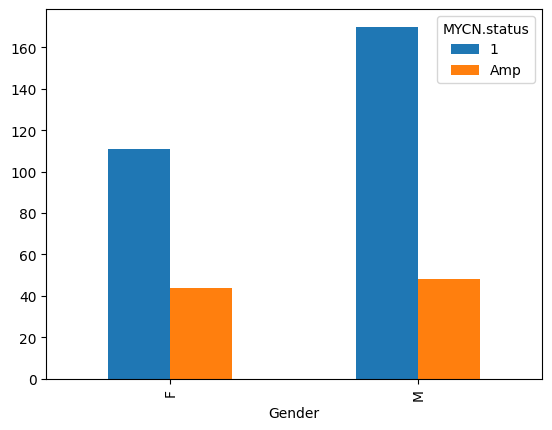

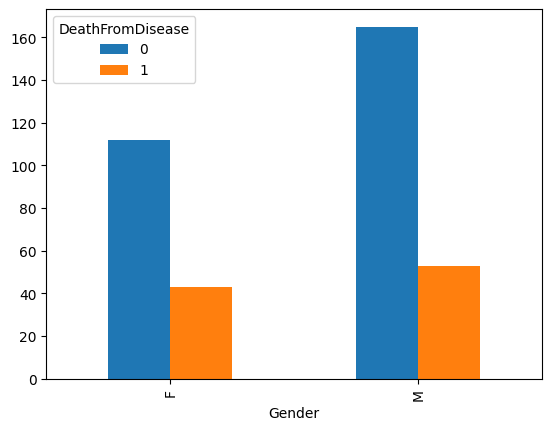

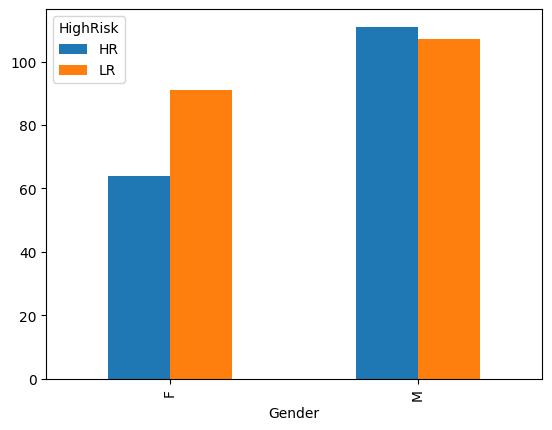

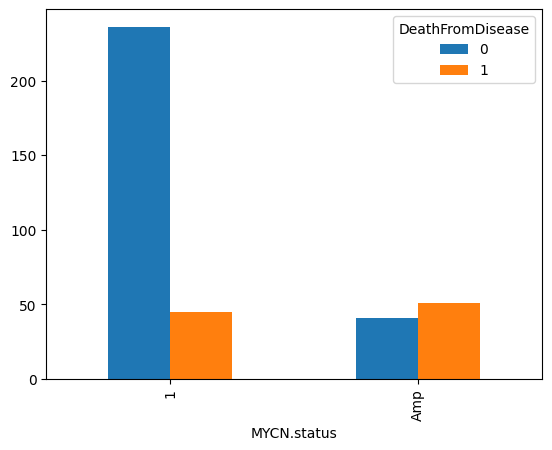

In [11]:
# Few exploratory bar charts
cross_comparison('Gender', 'MYCN.status')
plt.savefig("figures/gender_mycn.png", dpi=300, bbox_inches="tight")
cross_comparison('Gender', 'DeathFromDisease')
plt.savefig("figures/gender_death.png", dpi=300, bbox_inches="tight")
cross_comparison('Gender', 'HighRisk')
plt.savefig("figures/gender_risk.png", dpi=300, bbox_inches="tight")
cross_comparison('MYCN.status', 'DeathFromDisease')
plt.savefig("figures/mycn_death.png", dpi=300, bbox_inches="tight")

INSS.Stage   1  2  2a  2b  3    4  4S
Gender                               
F           57  0   2   1  6   70  19
M           63  1   1   0  9  111  33


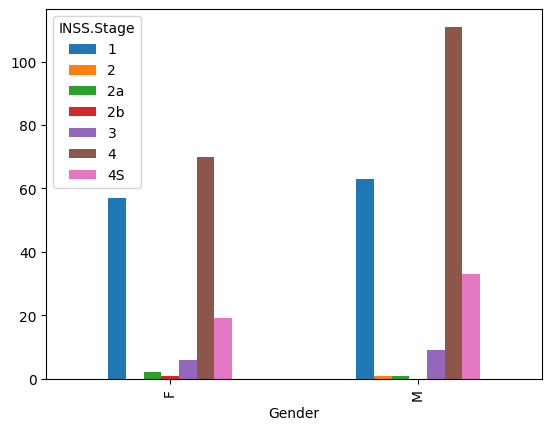

In [12]:
cross_comparison('Gender', 'INSS.Stage')
plt.savefig("figures/gender_inss.png", dpi=300, bbox_inches="tight")

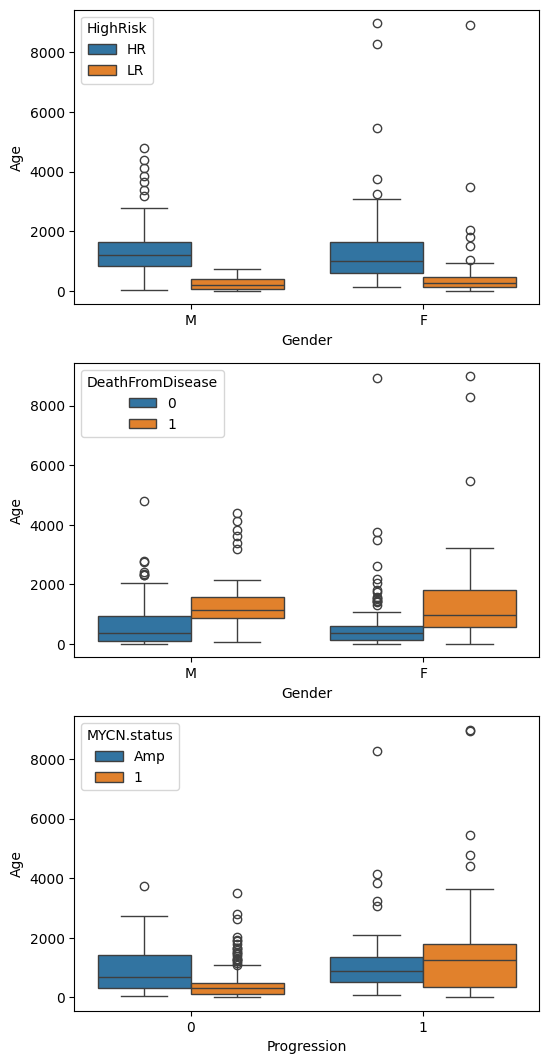

In [13]:
# Look at splits in relation to age

# Later try something like this please (unchanged code from own practice)
fig, axes = plt.subplots(3, 1, figsize=(6, 13))
sns.boxplot( x = "Gender", y = "Age", hue = 'HighRisk', ax=axes[0], data = df_patient_info )
sns.boxplot( x = "Gender", y = "Age", hue = 'DeathFromDisease', ax=axes[1], data = df_patient_info )
sns.boxplot( x = "Progression", y = "Age", hue = 'MYCN.status', ax=axes[2], data = df_patient_info )
plt.savefig("figures/eda_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# read microrarray data (note: renaming df_fpkm as df_ma_vals for clarity)
df_ma_vals = pd.read_csv(ma_vals)

In [15]:
print(df_ma_vals)

# 44708 rows = probes on the microarray
# 500 columns including probe ID (Reporter.Identifier), Gene symbol (GeneSymbols), then sample IDs in rest of columns
# Sample IDs have tage data still on them. Will have to be removed to conform to ID format in patient data

print("\nCount of NaN in each column:\n", df_ma_vals.isnull().sum())
# 498 gene profiles but only 373 patient records; will have to filter gene data (df_ma_vals) for shared values
# A lot of NaN data in each column ~5700 missing in gene values. 

       Reporter.Identifier GeneSymbols  ICGC_001_TCGA  ICGC_002_TCGA  \
0                      NaN         NaN          14.99          14.94   
1                  27262.0         NaN           9.20          10.41   
2                   3180.0         NaN           5.06           5.26   
3                  41426.0         NaN           7.45           8.68   
4                  37033.0         NaN           6.74           6.63   
...                    ...         ...            ...            ...   
44703              22435.0         NaN          10.35          10.33   
44704              17350.0         NaN          17.05          16.62   
44705              28875.0         NaN           5.30           6.84   
44706               8993.0         NaN          13.91          13.57   
44707              32006.0         NaN          14.54            NaN   

       ICGC_003_TCGA  ICGC_004  ICGC_005  ICGC_006  ICGC_007  ICGC_008  ...  \
0              12.48     14.63     11.89     15.09     1

In [16]:
# String to search for in column names
search_string = "_TCGA"

# Count number of columns containing the string
matching_column_count = df_ma_vals.columns.str.contains(search_string).sum()

print(f"Number of columns containing '{search_string}':", matching_column_count)

# 200 columns with tag in it

Number of columns containing '_TCGA': 200


In [17]:
# Remove '_TCGA' from all column names that contain it
df_ma_vals.columns = df_ma_vals.columns.str.replace('_TCGA', '', regex=False)

In [18]:
# check that there are no duplicate column names
print("Duplicated columns:", df_ma_vals.columns[df_ma_vals.columns.duplicated()])
print("Number of unique column names:", len(set(df_ma_vals.columns)))
print("Number of columns with same name:", (df_ma_vals.columns.value_counts()>1).sum())

Duplicated columns: Index([], dtype='object')
Number of unique column names: 500
Number of columns with same name: 0


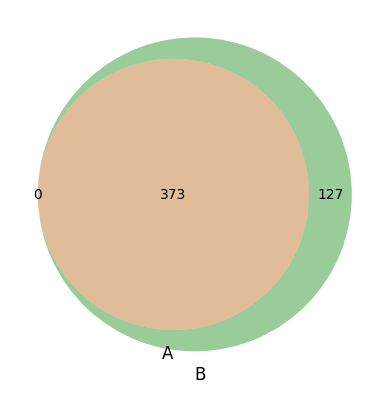

In [19]:
# Run this in terminal before running this (and subsequent) cells: pip3 install --user matplotlib-venn

# Quick visual check of overlapping sample IDs in two DFs
from matplotlib_venn import venn2

clinical_ids = set(df_patient_info['ID'])
sample_ids = set(df_ma_vals.columns)

# Use the venn2 function
venn2([set(clinical_ids), set(sample_ids)])
plt.savefig("figures/venn.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# filter gene data for samples present in clinical data

# Compare the values in 'ID' column of df_patient_info with the column names of df_ma_vals
shared_columns = df_patient_info['ID'].isin(df_ma_vals.columns).tolist()

# Use the list of shared columns to filter df_patient_info
matching_columns = df_patient_info['ID'][shared_columns].tolist()

# Filter df_ma_vals columns to match the shared values
df_ma_filtered = df_ma_vals[['Reporter.Identifier', 'GeneSymbols'] + matching_columns]

In [21]:
df_ma_filtered
# now have 373 samples

,Reporter.Identifier,GeneSymbols,ICGC_001,ICGC_002,ICGC_003,ICGC_004,ICGC_005,ICGC_006,ICGC_007,ICGC_008,...,ICGC_489,ICGC_490,ICGC_491,ICGC_492,ICGC_493,ICGC_494,ICGC_495,ICGC_496,ICGC_497,ICGC_498
0,NaN,NaN,14.99,14.94,12.48,14.63,11.89,15.09,13.07,12.00,...,13.62,13.03,14.98,13.36,13.90,13.00,13.79,14.70,14.03,12.31
1,27262.0,NaN,9.20,10.41,9.27,8.83,NaN,10.33,9.62,8.72,...,6.26,5.93,6.97,5.99,7.62,7.76,8.56,7.74,7.57,NaN
2,3180.0,NaN,5.06,5.26,6.45,2.89,2.00,4.80,3.05,6.39,...,0.93,0.58,1.26,1.38,3.49,2.07,2.26,2.29,NaN,2.54
3,41426.0,NaN,7.45,8.68,6.30,7.30,6.26,7.50,7.43,6.98,...,5.35,5.57,5.51,6.30,6.60,6.38,7.49,6.77,8.13,NaN
4,37033.0,NaN,6.74,6.63,6.75,6.20,6.57,6.01,6.78,4.80,...,4.58,4.61,3.54,4.55,4.20,7.16,7.07,5.07,6.28,6.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44703,22435.0,NaN,10.35,10.33,9.81,10.36,9.65,10.46,9.17,10.23,...,8.60,7.37,8.22,8.44,10.17,NaN,10.09,9.68,9.98,9.40
44704,17350.0,NaN,17.05,16.62,17.45,16.72,16.93,17.69,16.85,18.07,...,17.14,16.79,NaN,16.71,16.46,16.83,17.16,17.24,17.11,NaN
44705,28875.0,NaN,5.30,6.84,5.29,5.33,4.81,6.62,6.52,5.37,...,4.07,3.05,2.77,4.14,3.94,4.19,6.85,4.99,4.51,3.34
44706,8993.0,NaN,13.91,13.57,NaN,13.84,13.22,13.79,NaN,13.93,...,13.00,12.18,12.97,13.04,14.19,13.50,NaN,13.99,14.37,NaN


In [22]:
# count number of reporters with attached Gene Symbols
print(pd.crosstab(df_ma_filtered['GeneSymbols'], 'gene_count'))

# count number of genes that are assigned to more than one reporter
(pd.crosstab(df_ma_filtered['GeneSymbols'], 'gene_count')>1).sum()

# 7005 genes in ~44,000 rows, and 1400 relate to more than one probe

col_0        gene_count
GeneSymbols            
A2M                   1
AACS                  1
AADACL3               1
AAK1                  1
AAMDC                 1
...                 ...
ZSWIM6                1
ZUP1                  2
ZYG11B                1
ZZEF1                 1
ZZZ3                  4

[7005 rows x 1 columns]


col_0
gene_count    1400
dtype: int64

In [23]:
## Checkpoint 1
#df_ma_filtered.to_csv("data/df_ma_filtered.csv")
#df_patient_info.to_csv("data/df_patient_info.csv")

#df_ma_filtered = pd.read_csv("data/df_ma_filtered.csv", index_col=0)
#df_patient_info = pd.read_csv("data/df_patient_info.csv", index_col=0)

In [24]:
# determine if there are any missing values in microarray data
print("\nCount of NaN in each column:\n", df_ma_filtered.isnull().sum())

# 4471 Reporter.Identifier missing. These are pointless and can't be used for prediction


Count of NaN in each column:
 Reporter.Identifier     4471
GeneSymbols            35889
ICGC_001                5740
ICGC_002                5756
ICGC_003                5746
                       ...  
ICGC_494                5744
ICGC_495                5734
ICGC_496                5744
ICGC_497                5735
ICGC_498                5757
Length: 375, dtype: int64


In [25]:
# Remove NaN Reporters from df_ma_filtered
df_ma_filtered = df_ma_filtered.dropna(subset = ['Reporter.Identifier'])
df_ma_filtered

# 40237 rows left

,Reporter.Identifier,GeneSymbols,ICGC_001,ICGC_002,ICGC_003,ICGC_004,ICGC_005,ICGC_006,ICGC_007,ICGC_008,...,ICGC_489,ICGC_490,ICGC_491,ICGC_492,ICGC_493,ICGC_494,ICGC_495,ICGC_496,ICGC_497,ICGC_498
1,27262.0,NaN,9.20,10.41,9.27,8.83,NaN,10.33,9.62,8.72,...,6.26,5.93,6.97,5.99,7.62,7.76,8.56,7.74,7.57,NaN
2,3180.0,NaN,5.06,5.26,6.45,2.89,2.00,4.80,3.05,6.39,...,0.93,0.58,1.26,1.38,3.49,2.07,2.26,2.29,NaN,2.54
3,41426.0,NaN,7.45,8.68,6.30,7.30,6.26,7.50,7.43,6.98,...,5.35,5.57,5.51,6.30,6.60,6.38,7.49,6.77,8.13,NaN
4,37033.0,NaN,6.74,6.63,6.75,6.20,6.57,6.01,6.78,4.80,...,4.58,4.61,3.54,4.55,4.20,7.16,7.07,5.07,6.28,6.34
5,6190.0,NaN,NaN,4.05,4.91,3.00,NaN,3.50,3.58,4.00,...,0.77,0.68,1.38,1.43,2.07,2.20,2.41,2.38,2.72,2.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44703,22435.0,NaN,10.35,10.33,9.81,10.36,9.65,10.46,9.17,10.23,...,8.60,7.37,8.22,8.44,10.17,NaN,10.09,9.68,9.98,9.40
44704,17350.0,NaN,17.05,16.62,17.45,16.72,16.93,17.69,16.85,18.07,...,17.14,16.79,NaN,16.71,16.46,16.83,17.16,17.24,17.11,NaN
44705,28875.0,NaN,5.30,6.84,5.29,5.33,4.81,6.62,6.52,5.37,...,4.07,3.05,2.77,4.14,3.94,4.19,6.85,4.99,4.51,3.34
44706,8993.0,NaN,13.91,13.57,NaN,13.84,13.22,13.79,NaN,13.93,...,13.00,12.18,12.97,13.04,14.19,13.50,NaN,13.99,14.37,NaN


In [26]:
## Want to look at distribution of gene data; presence of outliers

# Summary statistics
print(df_ma_filtered.describe())

# on glance looks like data is pretty much in similar/same scale

       Reporter.Identifier      ICGC_001      ICGC_002      ICGC_003  \
count         40237.000000  35090.000000  35062.000000  35034.000000   
mean          22617.688272      9.142972      9.549795      8.864206   
std           13060.335213      3.120933      2.910794      2.986882   
min               1.000000      2.940000      2.790000      2.170000   
25%           11278.000000      7.050000      7.640000      6.920000   
50%           22625.000000      9.190000      9.510000      8.790000   
75%           33906.000000     11.280000     11.490000     10.800000   
max           45220.000000     18.960000     18.980000     18.840000   

           ICGC_004      ICGC_005      ICGC_006      ICGC_007      ICGC_008  \
count  35075.000000  35019.000000  35064.000000  35067.000000  35048.000000   
mean       8.874860      8.274384      9.353144      9.121953      8.921002   
std        3.316114      3.388349      2.936741      2.829272      3.164916   
min        2.540000      1.540000  

In [27]:
## Select first 10 reporters for further analysis
selected_rows = df_ma_filtered.iloc[0:10,2:]  

# Probe names
probe_names = df_ma_filtered.iloc[0:10, 0]  

# Probe names as row indices
selected_rows.index = probe_names
selected_rows

,ICGC_001,ICGC_002,ICGC_003,ICGC_004,ICGC_005,ICGC_006,ICGC_007,ICGC_008,ICGC_009,ICGC_010,...,ICGC_489,ICGC_490,ICGC_491,ICGC_492,ICGC_493,ICGC_494,ICGC_495,ICGC_496,ICGC_497,ICGC_498
Reporter.Identifier,,,,,,,,,,,,,,,,,,,,,
27262.0,9.20,10.41,9.27,8.83,NaN,10.33,9.62,8.72,9.36,8.41,...,6.26,5.93,6.97,5.99,7.62,7.76,8.56,7.74,7.57,NaN
3180.0,5.06,5.26,6.45,2.89,2.00,4.80,3.05,6.39,6.43,NaN,...,0.93,0.58,1.26,1.38,3.49,2.07,2.26,2.29,NaN,2.54
41426.0,7.45,8.68,6.30,7.30,6.26,7.50,7.43,6.98,8.02,7.31,...,5.35,5.57,5.51,6.30,6.60,6.38,7.49,6.77,8.13,NaN
37033.0,6.74,6.63,6.75,6.20,6.57,6.01,6.78,4.80,5.15,4.42,...,4.58,4.61,3.54,4.55,4.20,7.16,7.07,5.07,6.28,6.34
6190.0,NaN,4.05,4.91,3.00,NaN,3.50,3.58,4.00,NaN,2.56,...,0.77,0.68,1.38,1.43,2.07,2.20,2.41,2.38,2.72,2.63
21664.0,12.14,12.36,11.72,11.31,10.90,NaN,10.85,11.75,12.08,12.03,...,NaN,10.13,11.21,11.10,12.38,11.45,12.18,11.94,12.22,12.04
10745.0,3.04,4.10,4.27,4.12,3.10,4.07,NaN,2.87,4.32,2.51,...,1.54,0.49,1.20,1.26,4.22,3.45,2.29,NaN,2.49,NaN
13510.0,7.85,7.58,7.82,7.01,6.50,7.83,7.84,NaN,7.34,6.92,...,6.18,4.82,5.38,NaN,6.76,6.77,NaN,6.42,NaN,7.07
7298.0,17.86,17.78,18.19,18.22,18.15,18.12,17.65,18.54,17.98,18.63,...,17.80,NaN,17.47,17.85,17.57,17.82,17.92,17.99,17.75,17.65


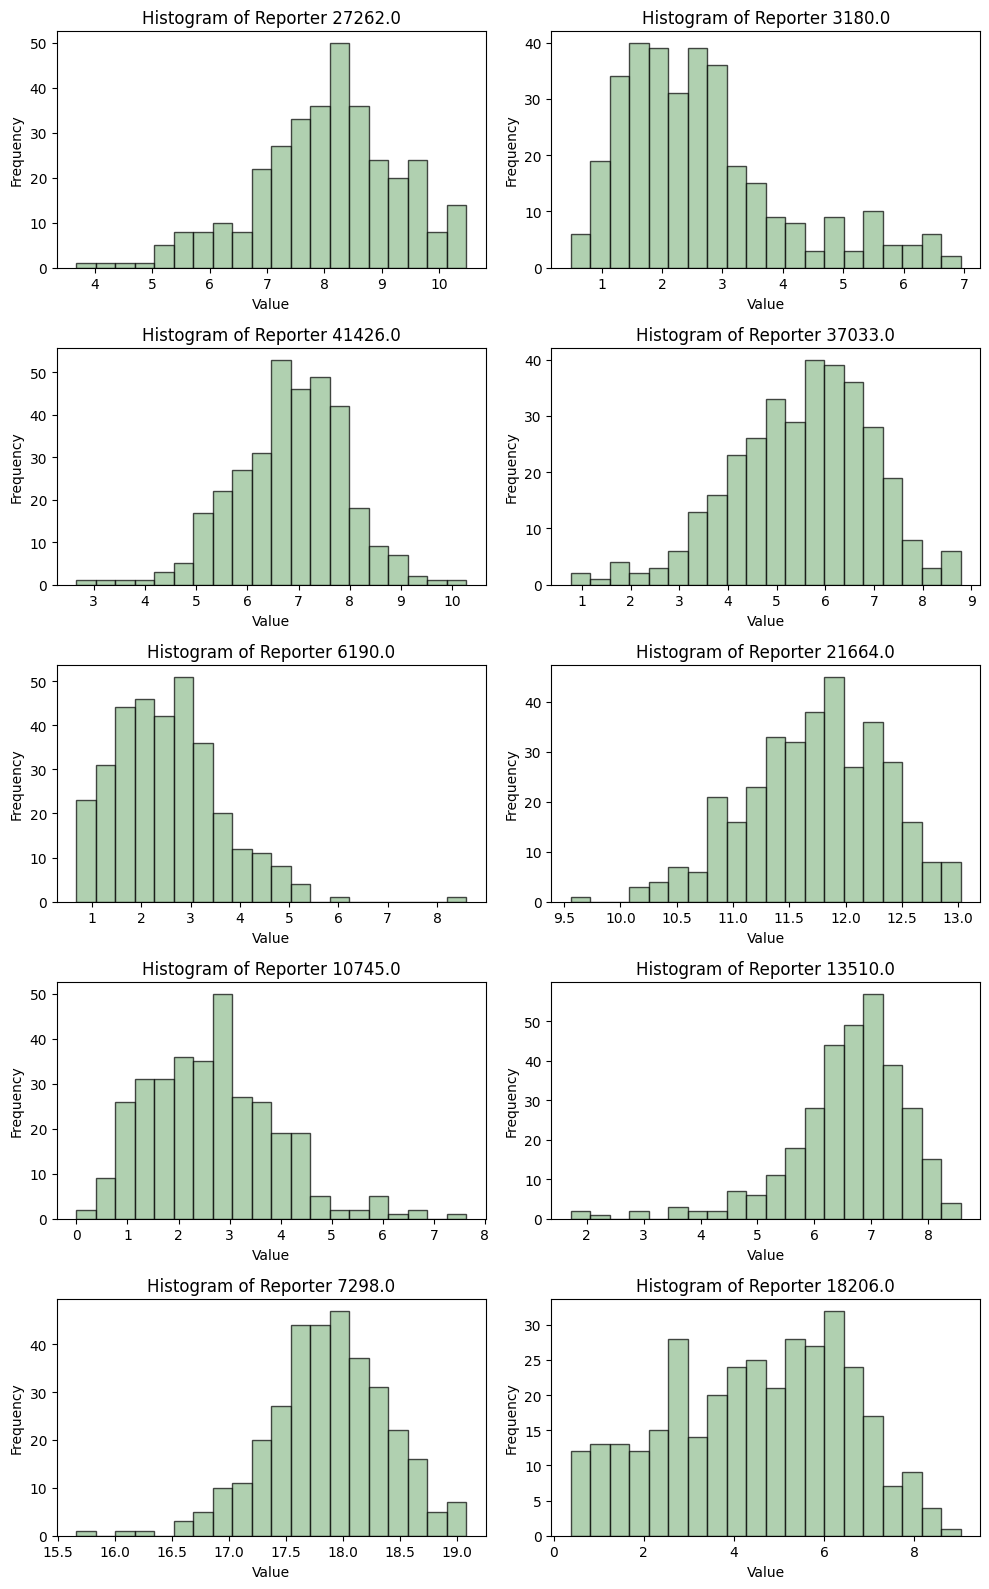

In [28]:
## Check distribution of first 10 probes

# Create subplots
fig, axes = plt.subplots(5, 2, figsize=(10, 16))  # 5 rows, 2 columns
axes = axes.flatten()  # Flatten array for easy iteration

for i, (index, row) in enumerate(selected_rows.iterrows()):  
    axes[i].hist(row, bins=20, alpha=0.7, color='darkseagreen', edgecolor='black')
    axes[i].set_title(f"Histogram of Reporter {index}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("figures/histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# Skewing evident; if I were using linear regression then log2-transformation would be required

In [29]:
# Pivot longer, keeping the first two columns as identifiers
#df_long = df_ma_filtered.melt(id_vars=["Reporter.Identifier", "GeneSymbols"], var_name="ID", value_name="Expression")

#df_long

# crashes when calculating correlation - keep as legacy

In [30]:
# Prepare data frames for merging
# Drop the first two columns and then transpose
df_ma_transposed = df_ma_filtered.iloc[:, 2:].T  # .iloc[:, 2:] excludes the first two columns


In [31]:
# Set colnames to Reporter.Identifier value (can later check if probe links to gene)
df_ma_transposed.columns = df_ma_filtered['Reporter.Identifier']

In [32]:
# View prepared gene data; BATCH EFFECT?? Can't detect without batch labels...
df_ma_transposed

Reporter.Identifier,27262.0,3180.0,41426.0,37033.0,6190.0,21664.0,10745.0,13510.0,7298.0,18206.0,...,3319.0,34832.0,24669.0,33950.0,39350.0,22435.0,17350.0,28875.0,8993.0,32006.0
ICGC_001,9.20,5.06,7.45,6.74,NaN,12.14,3.04,7.85,17.86,3.10,...,7.33,9.11,13.37,6.02,7.89,10.35,17.05,5.30,13.91,14.54
ICGC_002,10.41,5.26,8.68,6.63,4.05,12.36,4.10,7.58,17.78,5.93,...,7.94,9.95,NaN,8.32,NaN,10.33,16.62,6.84,13.57,NaN
ICGC_003,9.27,6.45,6.30,6.75,4.91,11.72,4.27,7.82,18.19,6.88,...,8.40,7.51,10.85,6.67,7.84,9.81,17.45,5.29,NaN,14.33
ICGC_004,8.83,2.89,7.30,6.20,3.00,11.31,4.12,7.01,18.22,6.78,...,NaN,8.54,10.04,7.28,8.20,10.36,16.72,5.33,13.84,14.76
ICGC_005,NaN,2.00,6.26,6.57,NaN,10.90,3.10,6.50,18.15,6.65,...,6.65,8.34,11.10,7.21,7.41,9.65,16.93,4.81,13.22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICGC_494,7.76,2.07,6.38,7.16,2.20,11.45,3.45,6.77,17.82,1.89,...,9.04,9.09,12.00,6.13,7.29,NaN,16.83,4.19,13.50,13.82
ICGC_495,8.56,2.26,7.49,7.07,2.41,12.18,2.29,NaN,17.92,6.02,...,8.79,9.57,12.67,7.41,8.20,10.09,17.16,6.85,NaN,14.82
ICGC_496,7.74,2.29,6.77,5.07,2.38,11.94,NaN,6.42,17.99,6.71,...,7.23,9.17,11.65,7.19,9.19,9.68,17.24,4.99,13.99,14.17
ICGC_497,7.57,NaN,8.13,6.28,2.72,12.22,2.49,NaN,17.75,5.22,...,NaN,9.38,12.01,6.34,8.65,9.98,17.11,4.51,14.37,14.65


In [33]:
# very basic PCA analysis of data with imputed values (median) for initial look-see

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# First remove all empty columns
df_ma_transposed_pca_only = df_ma_transposed.dropna(axis=1, how='all')

# Define preprocessing pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values with mean
    ('scaler', StandardScaler()),  # Scale features for PCA
    ('pca', PCA(n_components=20))  # Apply PCA; 20 components
])

# Apply pipeline
X_pca = pipeline.fit_transform(df_ma_transposed_pca_only)

# Access the PCA model from the pipeline
pca_model = pipeline.named_steps['pca']

# Get the loadings (eigenvectors)
loadings = pca_model.components_.T  # Transpose to align features with PCs

# Convert to DataFrame for readability
loadings_df = pd.DataFrame(loadings, 
                           index=df_ma_transposed_pca_only.columns,  # Feature names
                           columns=[f'PC{i+1}' for i in range(loadings.shape[1])])

df_pca_sorted = loadings_df.sort_values(by='PC1', ascending=False, key=abs)
df_pca_sorted

# Can check back after feature selection if these indices appear

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
Reporter.Identifier,,,,,,,,,,,,,,,,,,,,
26582.0,0.007468,-0.003079,0.003286,-0.001753,-0.005535,0.000335,-0.004160,0.001995,-0.002856,-0.000485,-0.001335,0.003365,0.004217,0.000646,-0.001389,-0.001281,-0.000007,0.004844,-0.010336,-0.000242
34688.0,0.007464,-0.003010,0.002830,0.002852,0.001367,-0.003891,-0.003396,0.003061,-0.001622,0.002100,-0.001224,0.005302,0.001414,-0.001661,0.001260,0.003475,-0.006550,-0.002819,0.000177,0.000039
16072.0,0.007450,-0.002954,0.003267,0.000654,-0.000909,-0.002238,0.000418,-0.000540,0.000354,0.003391,0.002966,0.005080,-0.002613,0.001969,-0.001111,0.000465,0.000029,-0.002268,-0.002534,-0.002637
33979.0,0.007449,-0.002822,0.000269,0.003442,-0.001806,-0.003183,-0.007090,0.003286,-0.006175,0.000006,0.002112,0.000984,0.003703,-0.002252,-0.001476,-0.000300,0.004166,0.001981,-0.007751,-0.000478
25845.0,0.007444,-0.003653,-0.000400,-0.003604,-0.003997,-0.002041,-0.001528,-0.001200,-0.005466,0.002018,0.000255,0.003419,-0.004493,0.000209,0.001585,-0.002527,-0.000577,0.001350,-0.001557,-0.000212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39180.0,0.000014,0.010043,0.008346,0.000634,0.000443,0.002012,0.000948,0.014610,-0.001282,-0.003478,0.009789,-0.004210,-0.005721,0.001450,-0.011799,0.002420,0.005119,-0.006514,-0.005926,-0.006737
23942.0,0.000013,0.012264,0.009165,-0.000663,0.002787,0.001193,0.000307,0.014602,0.003716,-0.006466,0.000707,-0.002263,-0.002259,0.000907,-0.007678,-0.003523,0.002507,-0.003937,-0.000944,0.002056
23749.0,0.000007,0.004254,0.006525,-0.000286,0.000183,0.004272,0.003863,0.002568,-0.006119,0.019345,-0.009883,-0.002225,-0.006748,0.019145,-0.000117,-0.008783,0.007791,-0.000146,-0.000870,-0.001457


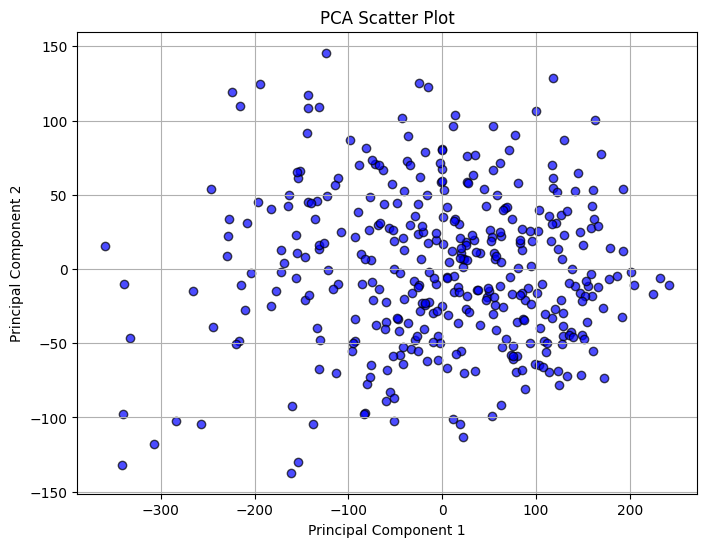

In [34]:
# Scatter plot of PCA-transformed data
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', alpha=0.7, edgecolors='k')

# Label the axes
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot")
plt.savefig("figures/PCA_EDA.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.grid(True)
plt.show()

In [35]:
## Carry on with merging clinical and genetic data

# Move ID column of clinical data into row indices
df_patient_info = df_patient_info.set_index('ID')

In [36]:
df_patient_info

,Gender,Age,clinico.genetic.subgroup,MYCN.status,INSS.Stage,HighRisk,Progression,DeathFromDisease
ID,,,,,,,,
ICGC_001,M,987.0,ST4,1,4,HR,1,1
ICGC_002,M,1808.0,ST4,1,4,HR,1,1
ICGC_003,F,625.0,MNA,Amp,4,HR,1,1
ICGC_004,F,335.0,MNA,Amp,2b,HR,0,0
ICGC_005,F,536.0,MNA,Amp,4,HR,1,1
...,...,...,...,...,...,...,...,...
ICGC_494,M,56.0,ST1,1,1,LR,0,0
ICGC_495,M,163.0,ST1,1,1,LR,0,0
ICGC_496,M,132.0,ST1,1,1,LR,1,0


In [37]:
# merged gene and clinical data
merged_df = pd.merge(df_patient_info, df_ma_transposed, left_index=True, right_index=True) # merge on row index

In [38]:
## Checkpoint 2
#merged_df.to_csv("data/merged_df.csv")

#merged_df = pd.read_csv("data/merged_df.csv", low_memory=False)
#merged_df = merged_df.set_index('ID')
## Warning: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False

In [39]:
merged_df

,Gender,Age,clinico.genetic.subgroup,MYCN.status,INSS.Stage,HighRisk,Progression,DeathFromDisease,27262.0,3180.0,...,3319.0,34832.0,24669.0,33950.0,39350.0,22435.0,17350.0,28875.0,8993.0,32006.0
ID,,,,,,,,,,,,,,,,,,,,,
ICGC_001,M,987.0,ST4,1,4,HR,1,1,9.20,5.06,...,7.33,9.11,13.37,6.02,7.89,10.35,17.05,5.30,13.91,14.54
ICGC_002,M,1808.0,ST4,1,4,HR,1,1,10.41,5.26,...,7.94,9.95,NaN,8.32,NaN,10.33,16.62,6.84,13.57,NaN
ICGC_003,F,625.0,MNA,Amp,4,HR,1,1,9.27,6.45,...,8.40,7.51,10.85,6.67,7.84,9.81,17.45,5.29,NaN,14.33
ICGC_004,F,335.0,MNA,Amp,2b,HR,0,0,8.83,2.89,...,NaN,8.54,10.04,7.28,8.20,10.36,16.72,5.33,13.84,14.76
ICGC_005,F,536.0,MNA,Amp,4,HR,1,1,NaN,2.00,...,6.65,8.34,11.10,7.21,7.41,9.65,16.93,4.81,13.22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICGC_494,M,56.0,ST1,1,1,LR,0,0,7.76,2.07,...,9.04,9.09,12.00,6.13,7.29,NaN,16.83,4.19,13.50,13.82
ICGC_495,M,163.0,ST1,1,1,LR,0,0,8.56,2.26,...,8.79,9.57,12.67,7.41,8.20,10.09,17.16,6.85,NaN,14.82
ICGC_496,M,132.0,ST1,1,1,LR,1,0,7.74,2.29,...,7.23,9.17,11.65,7.19,9.19,9.68,17.24,4.99,13.99,14.17


In [40]:
y_data = merged_df[['INSS.Stage', 'HighRisk', 'DeathFromDisease', 'Progression']]
y_data

# categorical output in y is acceptable

,INSS.Stage,HighRisk,DeathFromDisease,Progression
ID,,,,
ICGC_001,4,HR,1,1
ICGC_002,4,HR,1,1
ICGC_003,4,HR,1,1
ICGC_004,2b,HR,0,0
ICGC_005,4,HR,1,1
...,...,...,...,...
ICGC_494,1,LR,0,0
ICGC_495,1,LR,0,0
ICGC_496,1,LR,0,1


In [41]:
x_data = merged_df.drop(['INSS.Stage', 'HighRisk', 'DeathFromDisease', 'Progression'], axis=1)
x_data

# x data includes categorical values (Gender, c.g.s, MYCN-status)

,Gender,Age,clinico.genetic.subgroup,MYCN.status,27262.0,3180.0,41426.0,37033.0,6190.0,21664.0,...,3319.0,34832.0,24669.0,33950.0,39350.0,22435.0,17350.0,28875.0,8993.0,32006.0
ID,,,,,,,,,,,,,,,,,,,,,
ICGC_001,M,987.0,ST4,1,9.20,5.06,7.45,6.74,NaN,12.14,...,7.33,9.11,13.37,6.02,7.89,10.35,17.05,5.30,13.91,14.54
ICGC_002,M,1808.0,ST4,1,10.41,5.26,8.68,6.63,4.05,12.36,...,7.94,9.95,NaN,8.32,NaN,10.33,16.62,6.84,13.57,NaN
ICGC_003,F,625.0,MNA,Amp,9.27,6.45,6.30,6.75,4.91,11.72,...,8.40,7.51,10.85,6.67,7.84,9.81,17.45,5.29,NaN,14.33
ICGC_004,F,335.0,MNA,Amp,8.83,2.89,7.30,6.20,3.00,11.31,...,NaN,8.54,10.04,7.28,8.20,10.36,16.72,5.33,13.84,14.76
ICGC_005,F,536.0,MNA,Amp,NaN,2.00,6.26,6.57,NaN,10.90,...,6.65,8.34,11.10,7.21,7.41,9.65,16.93,4.81,13.22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICGC_494,M,56.0,ST1,1,7.76,2.07,6.38,7.16,2.20,11.45,...,9.04,9.09,12.00,6.13,7.29,NaN,16.83,4.19,13.50,13.82
ICGC_495,M,163.0,ST1,1,8.56,2.26,7.49,7.07,2.41,12.18,...,8.79,9.57,12.67,7.41,8.20,10.09,17.16,6.85,NaN,14.82
ICGC_496,M,132.0,ST1,1,7.74,2.29,6.77,5.07,2.38,11.94,...,7.23,9.17,11.65,7.19,9.19,9.68,17.24,4.99,13.99,14.17


In [42]:
# manually recode MYCN.status (there are only two values, so recode that 1 copy = 0 and Amp = 1)
x_data['MYCN.status'].replace('1', '0', inplace=True)
x_data['MYCN.status'].replace('Amp', '1', inplace=True)
x_data

,Gender,Age,clinico.genetic.subgroup,MYCN.status,27262.0,3180.0,41426.0,37033.0,6190.0,21664.0,...,3319.0,34832.0,24669.0,33950.0,39350.0,22435.0,17350.0,28875.0,8993.0,32006.0
ID,,,,,,,,,,,,,,,,,,,,,
ICGC_001,M,987.0,ST4,0,9.20,5.06,7.45,6.74,NaN,12.14,...,7.33,9.11,13.37,6.02,7.89,10.35,17.05,5.30,13.91,14.54
ICGC_002,M,1808.0,ST4,0,10.41,5.26,8.68,6.63,4.05,12.36,...,7.94,9.95,NaN,8.32,NaN,10.33,16.62,6.84,13.57,NaN
ICGC_003,F,625.0,MNA,1,9.27,6.45,6.30,6.75,4.91,11.72,...,8.40,7.51,10.85,6.67,7.84,9.81,17.45,5.29,NaN,14.33
ICGC_004,F,335.0,MNA,1,8.83,2.89,7.30,6.20,3.00,11.31,...,NaN,8.54,10.04,7.28,8.20,10.36,16.72,5.33,13.84,14.76
ICGC_005,F,536.0,MNA,1,NaN,2.00,6.26,6.57,NaN,10.90,...,6.65,8.34,11.10,7.21,7.41,9.65,16.93,4.81,13.22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICGC_494,M,56.0,ST1,0,7.76,2.07,6.38,7.16,2.20,11.45,...,9.04,9.09,12.00,6.13,7.29,NaN,16.83,4.19,13.50,13.82
ICGC_495,M,163.0,ST1,0,8.56,2.26,7.49,7.07,2.41,12.18,...,8.79,9.57,12.67,7.41,8.20,10.09,17.16,6.85,NaN,14.82
ICGC_496,M,132.0,ST1,0,7.74,2.29,6.77,5.07,2.38,11.94,...,7.23,9.17,11.65,7.19,9.19,9.68,17.24,4.99,13.99,14.17


In [43]:
# manually recode Gender (there are only two values, so recode that F = 0 and M = 1)
x_data['Gender'].replace('F', '0', inplace=True)
x_data['Gender'].replace('M', '1', inplace=True)
x_data

,Gender,Age,clinico.genetic.subgroup,MYCN.status,27262.0,3180.0,41426.0,37033.0,6190.0,21664.0,...,3319.0,34832.0,24669.0,33950.0,39350.0,22435.0,17350.0,28875.0,8993.0,32006.0
ID,,,,,,,,,,,,,,,,,,,,,
ICGC_001,1,987.0,ST4,0,9.20,5.06,7.45,6.74,NaN,12.14,...,7.33,9.11,13.37,6.02,7.89,10.35,17.05,5.30,13.91,14.54
ICGC_002,1,1808.0,ST4,0,10.41,5.26,8.68,6.63,4.05,12.36,...,7.94,9.95,NaN,8.32,NaN,10.33,16.62,6.84,13.57,NaN
ICGC_003,0,625.0,MNA,1,9.27,6.45,6.30,6.75,4.91,11.72,...,8.40,7.51,10.85,6.67,7.84,9.81,17.45,5.29,NaN,14.33
ICGC_004,0,335.0,MNA,1,8.83,2.89,7.30,6.20,3.00,11.31,...,NaN,8.54,10.04,7.28,8.20,10.36,16.72,5.33,13.84,14.76
ICGC_005,0,536.0,MNA,1,NaN,2.00,6.26,6.57,NaN,10.90,...,6.65,8.34,11.10,7.21,7.41,9.65,16.93,4.81,13.22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICGC_494,1,56.0,ST1,0,7.76,2.07,6.38,7.16,2.20,11.45,...,9.04,9.09,12.00,6.13,7.29,NaN,16.83,4.19,13.50,13.82
ICGC_495,1,163.0,ST1,0,8.56,2.26,7.49,7.07,2.41,12.18,...,8.79,9.57,12.67,7.41,8.20,10.09,17.16,6.85,NaN,14.82
ICGC_496,1,132.0,ST1,0,7.74,2.29,6.77,5.07,2.38,11.94,...,7.23,9.17,11.65,7.19,9.19,9.68,17.24,4.99,13.99,14.17


In [44]:
from sklearn.preprocessing import OneHotEncoder

# Convert categorical column to one-hot encoding
x_data = pd.get_dummies(x_data, columns=['clinico.genetic.subgroup'], dtype = int)

x_data

,Gender,Age,MYCN.status,27262.0,3180.0,41426.0,37033.0,6190.0,21664.0,10745.0,...,39350.0,22435.0,17350.0,28875.0,8993.0,32006.0,clinico.genetic.subgroup_MNA,clinico.genetic.subgroup_ST1,clinico.genetic.subgroup_ST4,clinico.genetic.subgroup_ST4S
ID,,,,,,,,,,,,,,,,,,,,,
ICGC_001,1,987.0,0,9.20,5.06,7.45,6.74,NaN,12.14,3.04,...,7.89,10.35,17.05,5.30,13.91,14.54,0,0,1,0
ICGC_002,1,1808.0,0,10.41,5.26,8.68,6.63,4.05,12.36,4.10,...,NaN,10.33,16.62,6.84,13.57,NaN,0,0,1,0
ICGC_003,0,625.0,1,9.27,6.45,6.30,6.75,4.91,11.72,4.27,...,7.84,9.81,17.45,5.29,NaN,14.33,1,0,0,0
ICGC_004,0,335.0,1,8.83,2.89,7.30,6.20,3.00,11.31,4.12,...,8.20,10.36,16.72,5.33,13.84,14.76,1,0,0,0
ICGC_005,0,536.0,1,NaN,2.00,6.26,6.57,NaN,10.90,3.10,...,7.41,9.65,16.93,4.81,13.22,NaN,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICGC_494,1,56.0,0,7.76,2.07,6.38,7.16,2.20,11.45,3.45,...,7.29,NaN,16.83,4.19,13.50,13.82,0,1,0,0
ICGC_495,1,163.0,0,8.56,2.26,7.49,7.07,2.41,12.18,2.29,...,8.20,10.09,17.16,6.85,NaN,14.82,0,1,0,0
ICGC_496,1,132.0,0,7.74,2.29,6.77,5.07,2.38,11.94,NaN,...,9.19,9.68,17.24,4.99,13.99,14.17,0,1,0,0


In [45]:
# Identify columns with all NaN values (no content)
empty_columns = x_data.columns[x_data.isnull().all()]
empty_columns

# there are 1292 columns with no data at all

# Drop columns with no content (all NaN)
x_data = x_data.dropna(axis=1, how='all')

x_data

,Gender,Age,MYCN.status,27262.0,3180.0,41426.0,37033.0,6190.0,21664.0,10745.0,...,39350.0,22435.0,17350.0,28875.0,8993.0,32006.0,clinico.genetic.subgroup_MNA,clinico.genetic.subgroup_ST1,clinico.genetic.subgroup_ST4,clinico.genetic.subgroup_ST4S
ID,,,,,,,,,,,,,,,,,,,,,
ICGC_001,1,987.0,0,9.20,5.06,7.45,6.74,NaN,12.14,3.04,...,7.89,10.35,17.05,5.30,13.91,14.54,0,0,1,0
ICGC_002,1,1808.0,0,10.41,5.26,8.68,6.63,4.05,12.36,4.10,...,NaN,10.33,16.62,6.84,13.57,NaN,0,0,1,0
ICGC_003,0,625.0,1,9.27,6.45,6.30,6.75,4.91,11.72,4.27,...,7.84,9.81,17.45,5.29,NaN,14.33,1,0,0,0
ICGC_004,0,335.0,1,8.83,2.89,7.30,6.20,3.00,11.31,4.12,...,8.20,10.36,16.72,5.33,13.84,14.76,1,0,0,0
ICGC_005,0,536.0,1,NaN,2.00,6.26,6.57,NaN,10.90,3.10,...,7.41,9.65,16.93,4.81,13.22,NaN,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICGC_494,1,56.0,0,7.76,2.07,6.38,7.16,2.20,11.45,3.45,...,7.29,NaN,16.83,4.19,13.50,13.82,0,1,0,0
ICGC_495,1,163.0,0,8.56,2.26,7.49,7.07,2.41,12.18,2.29,...,8.20,10.09,17.16,6.85,NaN,14.82,0,1,0,0
ICGC_496,1,132.0,0,7.74,2.29,6.77,5.07,2.38,11.94,NaN,...,9.19,9.68,17.24,4.99,13.99,14.17,0,1,0,0


In [46]:
# Ensure all column names are string

x_data.columns = x_data.columns.astype(str)

In [47]:
## VarianceThreshold - remove gene features with little or no variance; has to be done before standardization. At thr of 0.1 nothing is removed

#x_data_genes = x_data.iloc[:, 3:-4]

#from sklearn.feature_selection import VarianceThreshold
#def variance_threshold(df_x, thr):
#    var_thresholder = VarianceThreshold(threshold = thr)
#    var_thresholder.fit(df_x)
#    new_columns = var_thresholder.get_support()
#    return df_x.iloc[:, new_columns]

#x_data_lowvar_removed = variance_threshold(x_data_genes, thr = 1) 

#print(x_data_genes.shape)
#print(x_data_lowvar_removed.shape)

### Not necessary for RF. Will be incorporated in feature selection. 

In [48]:
# Split train and test before imputation and standardisation
# Split is 80/20; stratification is ONLY on DeathFromDisease

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42, stratify = y_data['DeathFromDisease'])

In [49]:
## Checkpoint 3

#X_train.to_csv("data/X_train.csv")
#X_test.to_csv("data/X_test.csv")

#y_train.to_csv("data/y_train.csv")
#y_test.to_csv("data/y_test.csv")

#X_train = pd.read_csv("data/X_train.csv")
#X_train = X_train.set_index('ID')
#X_test = pd.read_csv("data/X_test.csv")
#X_test = X_test.set_index('ID')

#y_train = pd.read_csv("data/y_train.csv")
#y_train = y_train.set_index('ID')
#y_test = pd.read_csv("data/y_test.csv")
#y_test = y_test.set_index('ID')

In [50]:
X_train

# There are no NaNs in the categorical columns

,Gender,Age,MYCN.status,27262.0,3180.0,41426.0,37033.0,6190.0,21664.0,10745.0,...,39350.0,22435.0,17350.0,28875.0,8993.0,32006.0,clinico.genetic.subgroup_MNA,clinico.genetic.subgroup_ST1,clinico.genetic.subgroup_ST4,clinico.genetic.subgroup_ST4S
ID,,,,,,,,,,,,,,,,,,,,,
ICGC_322,1,1611.0,1,7.99,NaN,4.80,7.43,3.35,12.47,3.09,...,8.85,10.15,17.63,5.00,13.60,14.34,1,0,0,0
ICGC_243,1,1640.0,0,7.49,2.32,7.54,5.30,1.85,NaN,2.56,...,7.29,9.54,16.34,3.25,NaN,14.54,0,0,1,0
ICGC_136,1,1679.0,1,NaN,2.54,6.68,6.70,2.66,11.90,4.21,...,7.72,NaN,NaN,5.96,14.08,14.74,1,0,0,0
ICGC_373,0,489.0,1,8.13,2.74,8.94,2.51,2.77,11.94,2.49,...,6.38,9.38,17.06,NaN,13.85,14.19,1,0,0,0
ICGC_354,0,267.0,0,8.07,2.56,NaN,4.70,1.89,NaN,1.49,...,7.46,10.04,17.67,3.26,13.86,15.05,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICGC_347,0,60.0,0,7.74,1.54,6.95,5.61,1.68,12.57,1.85,...,7.57,10.03,17.22,2.96,NaN,14.56,0,1,0,0
ICGC_013,1,3394.0,0,9.54,4.22,5.28,6.35,4.26,11.96,4.35,...,8.52,10.46,16.89,6.06,13.37,NaN,0,0,1,0
ICGC_452,0,240.0,0,7.13,1.20,6.57,2.46,1.72,11.14,1.14,...,6.84,NaN,16.31,2.61,12.94,NaN,0,1,0,0


In [51]:
# isolate gene data for imputation
X_train_selected = X_train.iloc[:, 3:-4]
X_test_selected = X_test.iloc[:, 3:-4]

In [52]:
#X_train_selected
#X_test_selected

In [53]:
# Impute missing values (required for both RF and SVM)
# Standardise data as matter of course (not required for RF but is for SVM)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import pandas as pd

# Define numeric transformation pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Apply transformations to all columns 
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, X_train_selected.columns)  # Apply to all columns
    ]
)


# Apply the transformations to the training set
X_train_selected_imputed = preprocessor.fit_transform(X_train_selected)

# Apply the transformations to the test set (only transform here)
X_test_selected_imputed = preprocessor.transform(X_test_selected)  

# Convert the output back to DataFrame 
X_train_selected = pd.DataFrame(X_train_selected_imputed, columns=X_train_selected.columns)
X_test_selected = pd.DataFrame(X_test_selected_imputed, columns=X_test_selected.columns)


In [54]:
# Ensure index tracks along
X_train_selected.index = X_train.index
X_test_selected.index = X_test.index

In [55]:
X_train_selected

,27262.0,3180.0,41426.0,37033.0,6190.0,21664.0,10745.0,13510.0,7298.0,18206.0,...,3319.0,34832.0,24669.0,33950.0,39350.0,22435.0,17350.0,28875.0,8993.0,32006.0
ID,,,,,,,,,,,,,,,,,,,,,
ICGC_322,-0.088702,-0.209070,-2.062630,1.371870,0.786651,1.243243,0.365406,0.663883,0.007568,-0.784332,...,0.604054,-1.383882,-1.805577,-1.318435,1.007055,0.819064,1.543746,0.321876,-0.096702,0.177432
ICGC_243,-0.513670,-0.267268,0.672314,-0.154450,-0.677754,0.067651,-0.082844,0.298720,-1.100301,0.836779,...,-1.144021,0.737878,-0.580746,0.048089,-0.412945,0.129984,-0.940231,-0.935395,0.166191,0.508105
ICGC_136,0.060038,-0.096554,-0.186099,0.848765,0.113025,0.292765,1.312652,0.521875,1.273704,0.602965,...,-1.100319,-0.209913,1.225095,0.575250,-0.021535,0.107391,0.061062,1.011579,0.873981,0.838779
ICGC_373,0.030290,0.058641,2.069731,-2.153715,0.220414,0.359465,-0.142047,-0.583757,1.273704,-0.893446,...,-0.226282,0.964055,-0.965469,-0.796392,-1.241278,-0.050758,0.446175,0.038092,0.408862,-0.070573
ICGC_354,-0.020707,-0.081035,0.083403,-0.584399,-0.638703,0.067651,-0.987803,0.947899,0.007568,0.088574,...,0.507910,0.285523,0.047372,-0.438127,-0.258201,0.694804,1.620769,-0.928211,0.429084,1.351322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICGC_347,-0.301186,-0.872528,0.083403,0.067691,-0.843720,1.409993,-0.683331,-0.289598,0.462586,-0.415426,...,-0.173840,1.642587,-0.996875,-0.233405,-0.158073,0.683507,0.754265,-1.143743,0.166191,0.541173
ICGC_013,1.228701,1.207081,-1.583516,0.597961,1.675056,0.392815,1.431058,0.765317,-0.348533,-0.477776,...,-0.269984,-0.780742,0.777560,-0.325530,0.706671,1.169252,0.118829,1.083423,-0.561820,0.061696
ICGC_452,-0.819648,-1.136359,-0.295896,-2.189544,-0.804669,-0.974539,-1.283817,-2.115413,-0.210049,-1.059714,...,-0.575897,1.039447,-0.274538,-1.134185,-0.822560,0.107391,-0.997998,-1.395197,-1.431390,0.061696


In [56]:
# create a list with df columns, to prepare for swap of data
columns_to_replace = X_train_selected.columns.tolist()


In [57]:
X_train[columns_to_replace] = X_train_selected[columns_to_replace]
X_test[columns_to_replace] = X_test_selected[columns_to_replace]

In [58]:
#X_test
#y_train

In [59]:
## Checkpoint 4 - saving X_train takes some time; consider doing it first on its own, then the rest

#X_train.to_csv("data/X_train_transformed.csv")
#X_test.to_csv("data/X_test_transformed.csv")

#y_train.to_csv("data/y_train_transformed.csv")
#y_test.to_csv("data/y_test_transformed.csv")

#X_train = pd.read_csv("data/X_train_transformed.csv")
#X_train = X_train.set_index('ID')
#X_test = pd.read_csv("data/X_test_transformed.csv")
#X_test = X_test.set_index('ID')

#y_train = pd.read_csv("data/y_train_transformed.csv")
#y_train = y_train.set_index('ID')
#y_test = pd.read_csv("data/y_test_transformed.csv")
#y_test = y_test.set_index('ID')

In [60]:
## Unsupervised analysis

from sklearn.decomposition import PCA

## PCA plot function

def pca_plot( df = None, target = None, tag = None, save_path = None ):
    pca = PCA(n_components=2)
    pca.fit(df)
    pca_variance = pca.explained_variance_ratio_.tolist()
    pca_variance[0] = pca_variance[0]*100
    pca_variance[1] = pca_variance[1]*100
    pca1lab = "PCA 1" + ", " + str(round(pca_variance[0], 2)) + "%"
    pca2lab = "PCA 2" + ", " + str(round(pca_variance[1], 2)) + "%"
    df_pca = pd.DataFrame(pca.transform(df), index=df.index, columns=['pca_1','pca_2'])
    plt.figure(figsize = (width, height))
    ax = sns.scatterplot(x=df_pca.iloc[:,0], y=df_pca.iloc[:,1], data=df,hue=target, palette=colors, edgecolor = 'white')
    plt.xlabel(pca1lab, fontsize = axis_)
    plt.ylabel(pca2lab, fontsize = axis_)
    plt.title("PCA : " + tag , fontsize = title_)
    plt.legend(title='Label', loc='upper right', fontsize = legend_, title_fontsize = legend_)
    plt.xticks(fontsize = ticks_)
    plt.yticks(fontsize = ticks_)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot saved as {save_path}")
    plt.show(block = False)
    return df_pca

In [61]:
pca = PCA(n_components=2)
pca.fit(X_train)
# Get the loadings (eigenvectors)
loadings2 = pca.components_.T  # Transpose to align features with PCs

# Convert to DataFrame for readability
loadings_df2 = pd.DataFrame(loadings2, 
                           index=X_train.columns,  # Feature names
                           columns=[f'PC{i+1}' for i in range(loadings2.shape[1])])

df_pca_sorted2 = loadings_df2.sort_values(by='PC1', ascending=False, key=abs)
df_pca_sorted2

,PC1,PC2
Age,9.998055e-01,0.012620
14416.0,3.697973e-04,0.000439
39308.0,3.634551e-04,0.002011
10433.0,-3.611733e-04,0.001832
5490.0,-3.600668e-04,0.003656
...,...,...
32333.0,-3.144140e-08,0.006074
16277.0,2.769628e-08,0.003542
26412.0,2.599310e-08,0.004942
22666.0,-5.482048e-09,0.005951


Plot saved as figures/pca_dfd.png


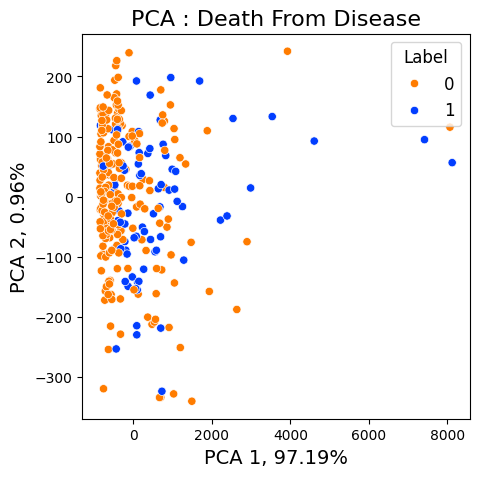

,pca_1,pca_2
ID,,
ICGC_322,755.840362,87.252609
ICGC_243,784.836973,15.629326
ICGC_136,823.691299,68.511516
ICGC_373,-365.371766,-23.362254
ICGC_354,-588.405182,53.478570
...,...,...
ICGC_347,-795.982567,32.773442
ICGC_013,2537.824643,130.145354
ICGC_452,-613.511181,-144.974463


In [62]:
# PCA colouring on DeathFromDisease; similar result with Progression; HighRisk returns nothing useful (no visible groups)

colorPalette = 'bright'
colors = dict(zip( y_train['DeathFromDisease'].unique() ,sns.color_palette(colorPalette)))
ticks_ = 10
legend_ = 12
axis_ = 14 
title_ = 16 
width = 5
height = 5

pca_plot( df = X_train, target = y_train['DeathFromDisease'], tag = "Death From Disease", save_path =  "figures/pca_dfd.png")

Plot saved as figures/pca_hr.png


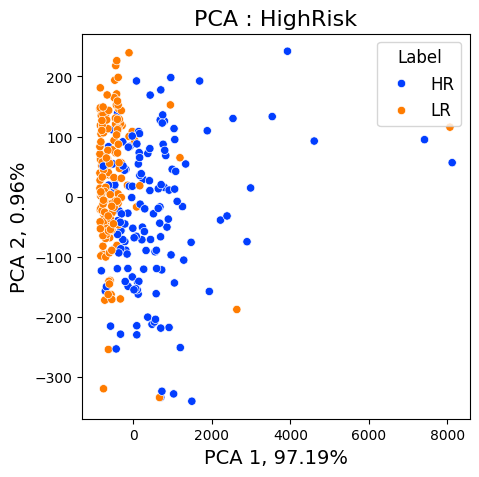

In [63]:
# PCA colouring on HighRisk

colorPalette = 'bright'
colors = dict(zip( y_train['HighRisk'].unique() ,sns.color_palette(colorPalette)))
ticks_ = 10
legend_ = 12
axis_ = 14 
title_ = 16 
width = 5
height = 5

df_pca = pca_plot( df = X_train, target = y_train['HighRisk'], tag = "HighRisk", save_path =  "figures/pca_hr.png" )

In [64]:
## Feature selection; hyperparameter tuning; model training

# Import necessary libraries
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif, SelectPercentile
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [98]:
# Overnight realised original strategy uses ONLY X_train for train and test, since I pre-split my data set
# need to rethink approach and use a sort of nested training approach

### AIM: train on X_train and y_train only using stratified k-fold, including feature selection and hyperparam tuning
# train on training folds of X_train and validate on test fold of X_train
# Validate on untouched X_test set

from sklearn.model_selection import StratifiedKFold
import numpy as np

## Specify the number of features
top_n_features = 30 # have squeezed this down from 200, 200 = 0.77 acc, 100 = 0.73 acc, 50 = 0.75 acc, 40 = 0.75

# Define hyperparameters to test
svm_params = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'poly', 'sigmoid']}
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}

# Initialize models
svm = SVC()
rf = RandomForestClassifier()

# Initialize lists to store accuracy scores
svm_accuracy_scores = []
rf_accuracy_scores = []

# Use StratifiedKFold within the training set
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store common features across folds
common_features_list = []

# set target values
y_train_select = y_train['DeathFromDisease']
y_test_select = y_test['DeathFromDisease']

for train_idx, val_idx in skf.split(X_train, y_train_select):
    
    # Split X_train into train and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_select.iloc[train_idx], y_train_select.iloc[val_idx]

    # Initialize feature selectors
    selector_kbest = SelectKBest(score_func=f_classif, k=top_n_features)
    selector_percentile = SelectPercentile(score_func=f_classif, percentile=1)

    # Fit and transform on training fold
    X_new_kbest = selector_kbest.fit_transform(X_train_fold, y_train_fold)
    X_new_percentile = selector_percentile.fit_transform(X_train_fold, y_train_fold)

    # Get selected features
    selected_features_kbest = X_train_fold.columns[selector_kbest.get_support()]
    selected_features_percentile = X_train_fold.columns[selector_percentile.get_support()]

    # Find common features
    common_features_fold = set(selected_features_kbest) & set(selected_features_percentile)
    common_features_list.append(common_features_fold)

# Find the intersection of features across all folds
final_common_features = set.intersection(*common_features_list)

# Subset the entire training and test sets to selected features
X_train_selected = X_train[list(final_common_features)]
X_test_selected = X_test[list(final_common_features)]

# Perform hyperparameter tuning on the selected features
# SVM
svm_grid_selected = GridSearchCV(svm, svm_params, cv=3)
svm_grid_selected.fit(X_train_selected, y_train_select)

# Random Forest
rf_grid_selected = GridSearchCV(rf, rf_params, cv=3)
rf_grid_selected.fit(X_train_selected, y_train_select)

# Get best models
svm_best_model = svm_grid_selected.best_estimator_
rf_best_model = rf_grid_selected.best_estimator_

# Evaluate on the final test set (untouched)
svm_y_pred = svm_best_model.predict(X_test_selected)
rf_y_pred = rf_best_model.predict(X_test_selected)

svm_accuracy = accuracy_score(y_test_select, svm_y_pred)
rf_accuracy = accuracy_score(y_test_select, rf_y_pred)

# Print final evaluation
print(f"Final Test Accuracy - SVM: {svm_accuracy:.4f}")
print(f"Final Test Accuracy - RF: {rf_accuracy:.4f}")
print("\nFinal Selected Features:", final_common_features)

# Print the best hyperparameters found for both models
print("\nBest SVM parameters on selected features: ", svm_grid_selected.best_params_)
print("Best RF parameters on selected features: ", rf_grid_selected.best_params_)

Final Test Accuracy - SVM: 0.7333
Final Test Accuracy - RF: 0.7733

Final Selected Features: {'11372.0', '35729.0', '26283.0', '41668.0', '21305.0', '1965.0', '9751.0', '3621.0', '5985.0', '28655.0'}

Best SVM parameters on selected features:  {'C': 0.1, 'kernel': 'sigmoid'}
Best RF parameters on selected features:  {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 50}


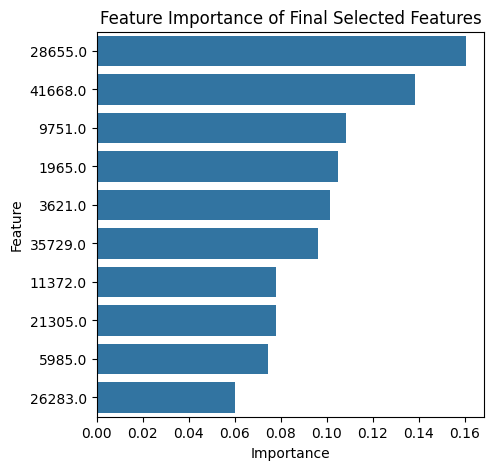

In [99]:
# Get the feature importances from the trained Random Forest model
importances_rf = rf_best_model.feature_importances_

# Create a DataFrame with feature names and their importance scores
importance_rf_df = pd.DataFrame({
    'Feature': list(final_common_features),
    'Importance': importances_rf
})

# Sort the features by their importance (descending)
importance_rf_df = importance_rf_df.sort_values(by='Importance', ascending=False)


# Plot the feature importances
plt.figure(figsize=(5, 5))
sns.barplot(x='Importance', y='Feature', data=importance_rf_df)
plt.title('Feature Importance of Final Selected Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.savefig("figures/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

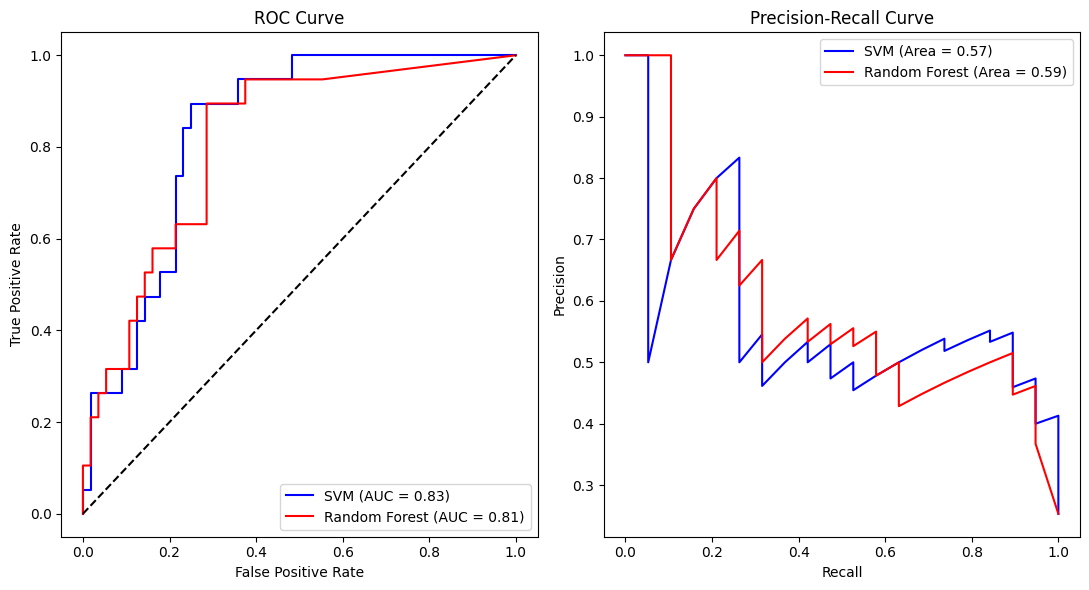

In [100]:
# Plot curves
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix, f1_score 

# If target is STRING, then run this code:
#from sklearn.preprocessing import LabelEncoder
#label_encoder = LabelEncoder()
#y_test_select = label_encoder.fit_transform(y_test_select)

# Get probabilities for ROC and PR curves
svm_y_prob = svm_best_model.decision_function(X_test_selected)  # Use decision_function for SVM
rf_y_prob = rf_best_model.predict_proba(X_test_selected)[:, 1]  # Use predict_proba for RF

# Compute ROC curve and AUC
svm_fpr, svm_tpr, _ = roc_curve(y_test_select, svm_y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test_select, rf_y_prob)

svm_auc = auc(svm_fpr, svm_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

# Compute Precision-Recall curve and Average Precision (AP)
svm_precision, svm_recall, _ = precision_recall_curve(y_test_select, svm_y_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test_select, rf_y_prob)

svm_ap = average_precision_score(y_test_select, svm_y_prob)
rf_ap = average_precision_score(y_test_select, rf_y_prob)

# Plot ROC Curve
plt.figure(figsize=(11, 6))
plt.subplot(1, 2, 1)
plt.plot(svm_fpr, svm_tpr, label="SVM (AUC = %0.2f)" % svm_auc, color='blue')
plt.plot(rf_fpr, rf_tpr, label="Random Forest (AUC = %0.2f)" % rf_auc, color='red')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(svm_recall, svm_precision, label="SVM (Area = %0.2f)" % auc(svm_recall, svm_precision), color='blue')
plt.plot(rf_recall, rf_precision, label="Random Forest (Area = %0.2f)" % auc(rf_recall, rf_precision), color='red')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.savefig("figures/ROC_PR.png", dpi=300, bbox_inches="tight")
plt.show()


In [101]:
# Performance metrics
def print_metrics(y_test, pred, prob):
    print('Accuracy:', accuracy_score(y_test, pred))
    print('F1 Score:', f1_score(y_test, pred))
    print('ROC AUC:', roc_auc_score(y_test, prob))
    precision, recall, _ = precision_recall_curve(y_test, prob)
    print('PR AUC:', auc(recall, precision))


In [102]:
# Performance of RF
print_metrics(y_test_select, rf_y_pred, rf_y_prob)

Accuracy: 0.7733333333333333
F1 Score: 0.5142857142857142
ROC AUC: 0.8124999999999999
PR AUC: 0.5866829412276064


In [103]:
# Performance of SVM
print_metrics(y_test_select, svm_y_pred, svm_y_prob)


Accuracy: 0.7333333333333333
F1 Score: 0.5
ROC AUC: 0.8345864661654134
PR AUC: 0.572873592647235


In [71]:
### To add: look at probe ID of markers identified as predictive; check if Gene ID is available

In [72]:
# Drop features that are highly correlated: for RF this isn't as important as feature selection (it is insensitive
# to correlation); for SVM correlation can affect model performance (especially radial kernel) BUT feature
# selection sorts this AND RFE will remove non-informative features when used as wrapper feature selection method

# If model performs poorly:
# "Most ML algos assume equal class size" - Imbalanced sets: get more data; don’t use ROC, adjust (random over/undersampling)
# first oversample then undersample

# check clustering, but see paper: https://www.nature.com/articles/6601326 
# check high-level shape with PCA or UMAP
# Naive Bayes would be nice but the data set is too big (?) and assumption of independence will almost certainly
# be violated since this is a custom array selected fro prediction of a specific cancer

In [104]:
probes = final_common_features
probes
probes_num = list(map(float, probes))
probes_num

[11372.0,
 35729.0,
 26283.0,
 41668.0,
 21305.0,
 1965.0,
 9751.0,
 3621.0,
 5985.0,
 28655.0]

In [6]:
genes = df_ma_vals.iloc[:,:2]
genes

,Reporter.Identifier,GeneSymbols
0,NaN,NaN
1,27262.0,NaN
2,3180.0,NaN
3,41426.0,NaN
4,37033.0,NaN
...,...,...
44703,22435.0,NaN
44704,17350.0,NaN
44705,28875.0,NaN
44706,8993.0,NaN


In [106]:
filtered_genes = genes[genes['Reporter.Identifier'].isin(probes_num)]
filtered_genes

,Reporter.Identifier,GeneSymbols
1930,1965.0,NaN
7271,28655.0,NaN
7771,26283.0,NaN
20218,5985.0,NaN
25054,35729.0,CTF1
26318,9751.0,NaN
28927,3621.0,NaN
29714,41668.0,NaN
30189,11372.0,NaN
35849,21305.0,NaN


In [8]:
HR = [34105.0, 1995.0, 32099.0, 2731.0, 34728.0, 14867.0, 23272.0, 3150.0, 9458.0, 23224.0, 45207.0]
genes_HR = genes[genes['Reporter.Identifier'].isin(HR)]
genes_HR

,Reporter.Identifier,GeneSymbols
1303,32099.0,NaN
3558,3150.0,NaN
10426,14867.0,NaN
14419,34728.0,ADAMTS5
16375,34105.0,MTMR9LP
24360,45207.0,SLC5A4-AS1|CPSF1
24927,23224.0,NaN
27573,9458.0,NaN
29968,23272.0,NaN
36431,2731.0,NaN


In [9]:
Prog = [17520.0, 4881.0, 28655.0]
genes_Prog = genes[genes['Reporter.Identifier'].isin(Prog)]
genes_Prog

,Reporter.Identifier,GeneSymbols
7271,28655.0,NaN
25480,4881.0,NaN
35684,17520.0,NaN


In [ ]:
Prog = ['clinico.genetic.subgroup_ST1', '35733.0', '10772.0', 'clinico.genetic.subgroup_ST, 22495.0, 2731.0, 34728.0, 14867.0, 39434.0, 8310.0, 2396.0, 9458.0, 23224.0, 44212.0]
genes_Prog = genes[genes['Reporter.Identifier'].isin(Prog)]
genes_Prog